# Pure CO₂ Surface Tension — SR Pipeline

| Step | Script | Produces |
|------|--------|---------|
| **1 — Run Part 1 below** | `Pure_component.ipynb` | `pure_component_results.csv` |
| **2 — Run in terminal** | `julia --threads auto CO2.jl` | `outputs/hall_of_fame_gamma.jls` + timestamped CSV |
| **3 — Run Part 2 below** | `Pure_component.ipynb` | choose equation → comparison plot |

---
## Part 1 — Generate PC-SAFT + cDFT Data

In [1]:
import time
notebook_start = time.perf_counter()
# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps
import numpy as np, matplotlib.pyplot as plt
import json, pathlib, thermoift
import pandas as pd
import glob, re
import sys
sys.path.insert(0, '/home/darshan/A6/PCSAFT_cDFT/Interfacethermopy/src')
from Interfacethermopy.Interfacethermopy import InterfacialTension

In [2]:
_records = json.loads((pathlib.Path(thermoift.__file__).parent / "parameters.json").read_text())

_hdr = f"{'Component':<20} {'m':>8} {'sigma(A)':>10} {'eps/k(K)':>10} {'q':>8} {'mu':>8}"
print("PC-SAFT / PCP-SAFT parameters loaded by SEC")
print(_hdr)
print("-" * len(_hdr))
for r in _records:
    name = r["identifier"]["name"]
    print(
        f"{name:<20}"
        f" {str(r.get('m',         '--')):>8}"
        f" {str(r.get('sigma',     '--')):>10}"
        f" {str(r.get('epsilon_k', '--')):>10}"
        f" {str(r.get('q',         '--')):>8}"
        f" {str(r.get('mu',        '--')):>8}"
    )

PC-SAFT / PCP-SAFT parameters loaded by SEC
Component                   m   sigma(A)   eps/k(K)        q       mu
---------------------------------------------------------------------
carbon dioxide         1.6298     3.0867     163.34   3.9546       --
hydrogen                 0.68       3.54      31.57       --       --
nitrogen               1.1879     3.3353      90.99   1.1151       --
argon                     1.0    3.37751  117.80903       --       --
methane                   1.0    3.70051  150.07147       --       --
oxygen                1.14702    3.17933  113.62724       --       --
carbon monoxide       1.32286    3.24532   91.17087       --       --
hydrogen sulfide        1.333      3.332     235.54    2.938    0.978


In [3]:
model = SEC.semi_emperical_correlations()
name = "carbon dioxide"
T_vals = np.arange(220, 309, 1)

force_recompute = False  # set True to regenerate even if CSV exists

if not force_recompute and pathlib.Path("pure_component_results.csv").exists():
    print("Loading existing pure_component_results.csv ...")
    df = pd.read_csv("pure_component_results.csv")
else:
    rows = []
    for T_K in T_vals:
        gamma0, rhoL0, rhoV0, Tc, Pc, Psat = model._pure_component_cDFT(name, T_K)
        if np.isnan(gamma0):
            continue
        rows.append((T_K, gamma0, rhoL0, rhoV0, Tc, Pc, Psat))

    df = pd.DataFrame(rows, columns=['T_K', 'gamma', 'rhoL', 'rhoV', 'Tc', 'Pc', 'Psat'])
    df.to_csv("pure_component_results.csv", index=False)
    print(f"Saved {len(df)} rows to pure_component_results.csv")

Loading existing pure_component_results.csv ...


In [4]:
_tc = float(df["Tc"].iloc[0])
_pc = float(df["Pc"].iloc[0])

_crit_files = [
    pathlib.Path("../component_Tc.json"),
    pathlib.Path("../../../PART_1/RESIDUAL/SR/Pure_fluid/component_Tc.json"),
]

for _p in _crit_files:
    _crit    = json.loads(_p.read_text())
    _old_tc  = _crit["carbon_dioxide"]["Tc"]
    _old_pc  = _crit["carbon_dioxide"]["Pc"]
    _crit["carbon_dioxide"]["Tc"] = _tc
    _crit["carbon_dioxide"]["Pc"] = _pc
    _p.write_text(json.dumps(_crit, indent=4))
    print(f"{_p}")
    print(f"  Tc: {_old_tc:.6f}  ->  {_tc:.6f} K")
    print(f"  Pc: {_old_pc:.6f}  ->  {_pc:.6f} bar")

../component_Tc.json
  Tc: 302.710658  ->  302.710658 K
  Pc: 75.512215  ->  75.512215 bar
../../../PART_1/RESIDUAL/SR/Pure_fluid/component_Tc.json
  Tc: 302.710658  ->  302.710658 K
  Pc: 75.512215  ->  75.512215 bar


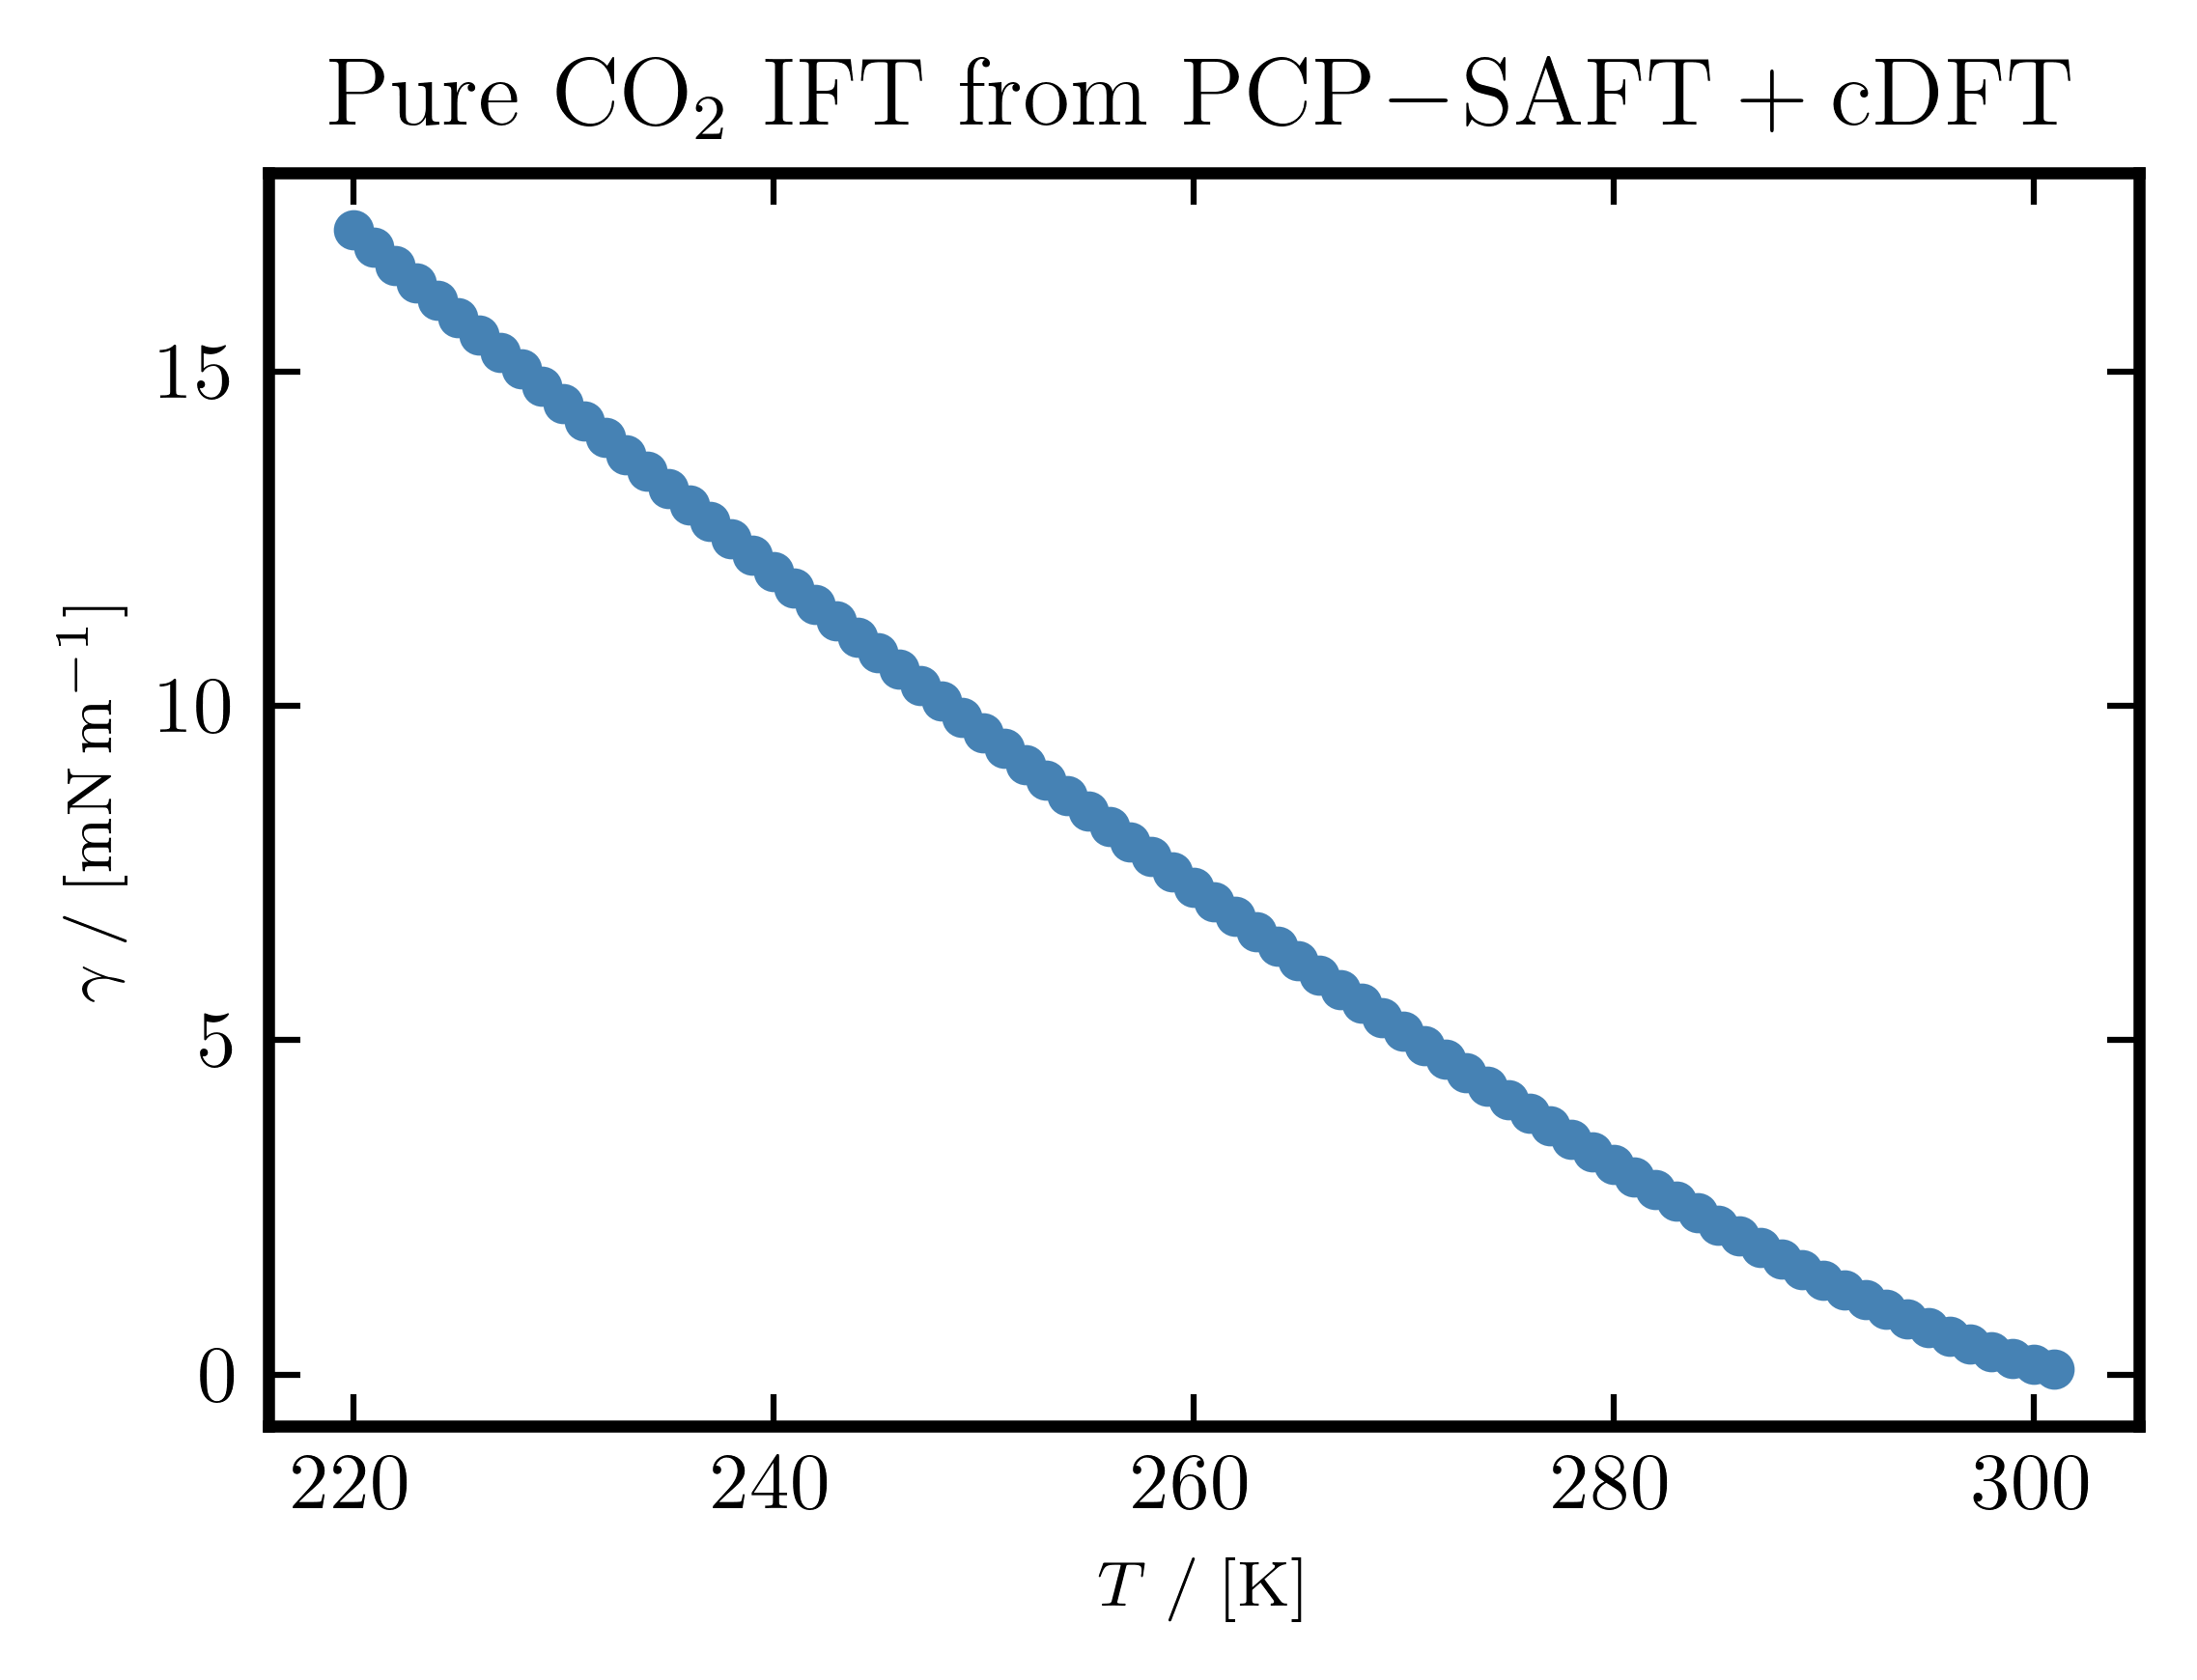

In [5]:
fig, ax = ps.plot_init()
ax.plot(df['T_K'], df['gamma'], "o-", markersize=4, color="steelblue")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$")
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$")
ax.set_title(r"$\mathrm{Pure\ CO_{2}\ IFT\ from\ PCP\!-\!SAFT+cDFT}$")
plt.tight_layout()
plt.show()

---
## ⏸ Stop — Run `CO2.jl` Before Continuing

```bash
julia --threads auto CO2.jl
```

Outputs written to `outputs/`:
- `hall_of_fame_gamma.jls` — serialised Pareto frontier (used by Part 2)
- `<timestamp>/hall_of_fame.csv` — equation table (read below)
- `equations_gamma.tex` / `.pdf` — LaTeX render

---
## Part 2 — Select Equation & Compare

In [6]:
import glob
import sympy as sp

# ── locate latest hall_of_fame.csv ──────────────────────────────────────────
_csvs = sorted(glob.glob("outputs/*/hall_of_fame.csv"))
assert _csvs, "No hall_of_fame.csv found - run CO2.jl first (Step 2)."
hof_path = _csvs[-1]
hof_df   = pd.read_csv(hof_path).reset_index(drop=True)

# ── sympy-based canonical extractor  σ = Σ sᵢ (1-Tr)^nᵢ ────────────────────
_F1 = sp.Symbol('F1', positive=True)

def _parse_sympy(eq_str):
    return eval(eq_str.strip(), {'__builtins__': {}},
                {'safepow': sp.Pow, 'F1': _F1})

def _extract_term(t):
    """(coeff, exp) if t = coeff * F1**n with numeric n, else None."""
    if not t.has(_F1):
        return (float(t), 0.0)
    if t is _F1:
        return (1.0, 1.0)
    if isinstance(t, sp.Pow) and t.base is _F1 and not t.exp.has(_F1):
        return (1.0, float(t.exp))
    if isinstance(t, sp.Mul):
        coeff, n_exp = sp.S.One, None
        for f in t.args:
            if not f.has(_F1):
                coeff *= f
            elif f is _F1:
                if n_exp is not None: return None
                n_exp = sp.S.One
            elif isinstance(f, sp.Pow) and f.base is _F1 and not f.exp.has(_F1):
                if n_exp is not None: return None
                n_exp = f.exp
            else:
                return None
        if n_exp is None: return None
        return (float(coeff), float(n_exp))
    return None

def extract_canonical(eq_str):
    """Returns sorted [(s, n), ...] or None if not expressible in canonical form."""
    try:
        expr = sp.expand(sp.simplify(_parse_sympy(eq_str)))
    except Exception:
        return None
    parts = expr.args if isinstance(expr, sp.Add) else [expr]
    result = [_extract_term(t) for t in parts]
    if any(r is None for r in result):
        return None
    return sorted(result, key=lambda x: -x[1])

def fmt_canonical(terms, sig=5):
    pieces = []
    for s, n in terms:
        ss = f"{s:.{sig}g}"
        if abs(n) < 1e-9:        pieces.append(ss)
        elif abs(n - 1) < 1e-9: pieces.append(f"{ss}*(1-Tr)")
        else:                    pieces.append(f"{ss}*(1-Tr)^{n:.{sig}g}")
    return "sigma = " + " + ".join(pieces)

def fmt_sympy(eq_str):
    """Sympy-simplified fallback — cleaner than the raw SR string."""
    try:
        expr = sp.simplify(_parse_sympy(eq_str))
        return str(expr).replace("F1", "(1-Tr)").replace("**", "^")
    except Exception:
        return eq_str

# ── display ──────────────────────────────────────────────────────────────────
print(f"SR run : {hof_path}\n")
print(f"{'#':<4} {'Cmplx':>5} {'RMSE':>12}   Canonical form  sigma = sum si*(1-T/Tc)^ni")
print("-" * 90)
for i, row in enumerate(hof_df.itertuples(index=False), 1):
    rmse = row.Loss ** 0.5
    canon = extract_canonical(row.Equation)
    label = fmt_canonical(canon) if canon is not None else "  " + fmt_sympy(row.Equation)
    print(f"{i:<4} {int(row.Complexity):>5} {rmse:>12.6g}   {label}")

SR run : outputs/20260515_161122_FkJQLz/hall_of_fame.csv

#    Cmplx         RMSE   Canonical form  sigma = sum si*(1-T/Tc)^ni
------------------------------------------------------------------------------------------
1        1      5.22737   sigma = 7.8887
2        3     0.877284   sigma = 57.556*(1-Tr)
3        5    0.0436987   sigma = 93.33*(1-Tr)^1.304
4        7    0.0162587     (35.1450848864491*(1-Tr) - 0.151838395829124)^1.26516882967802
5        9   0.00847472     (36.4392105782385*(1-Tr) - 0.326298717113166)^1.2504177491106 + 0.155678973066979
6       11   0.00020543     88.2709689758217*(1-Tr)^1.48893940522703/((1-Tr) + 0.0821170454377483)^0.281900884278262
7       13  0.000185643     (88.2728303580542*(1-Tr)^1.48707624722717 - 0.000321102902948467)/((1-Tr) + 0.0830678748711087)^0.280291639454068
8       15  0.000174191     (88.2676213244755*(1-Tr)^1.48736522109575 + 0.0840513828196083*((1-Tr) + 0.0861115965109412)^0.281506494555871 - 0.0432246981309332)/((1-Tr) + 0.0861115

In [ ]:
best_idx = 6   # ← set this after reviewing the equation table above (1-indexed)

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2901914/2673228693.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("$\mathrm{Complexity}$",         fontsize=ps.label_fontsize)


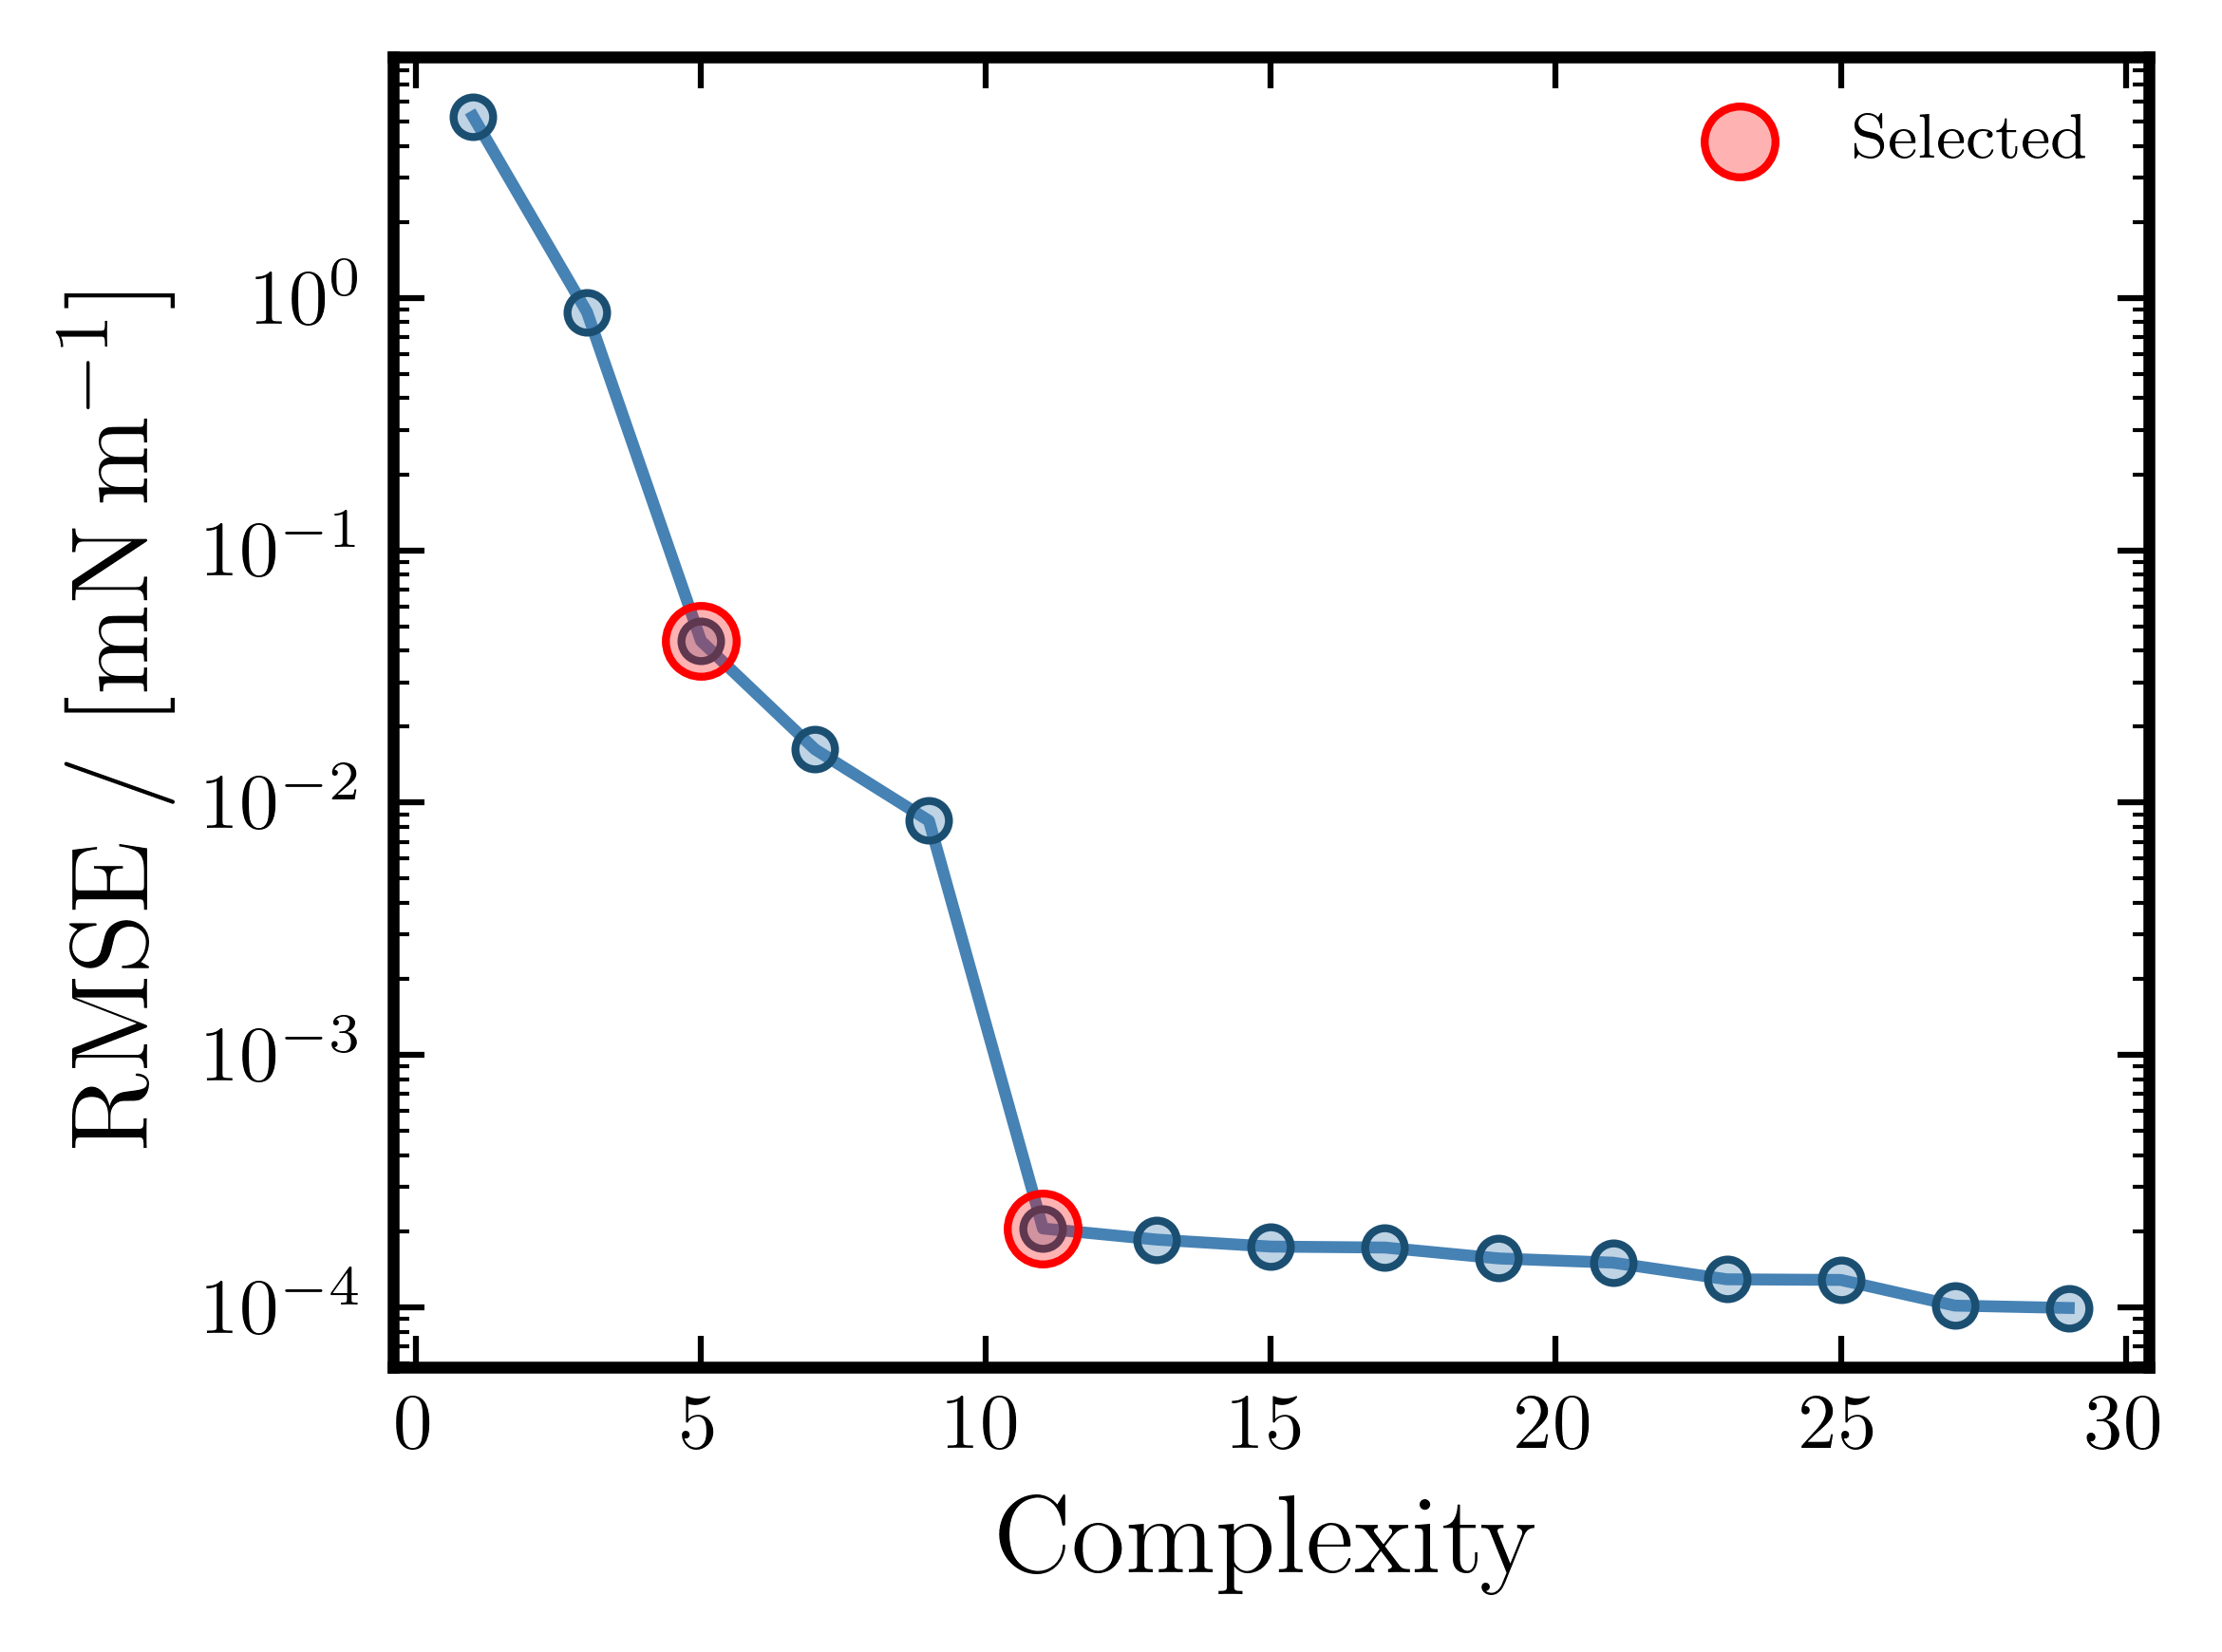

In [8]:
# ── Pareto front: complexity vs loss ────────────────────────────────────────

fig, ax = ps.plot_init()

complexities = hof_df["Complexity"].values
losses       = hof_df["Loss"].values ** 0.5

ax.plot(complexities, losses, "o-", color="steelblue",
        markeredgecolor="#1b4f72", markerfacecolor=(0.274, 0.510, 0.706, 0.35),
        markeredgewidth=1.0, markersize=5, lw=1.5)

# highlight the selected equation
ax.scatter(
    [hof_df.iloc[best_idx - 1]["Complexity"]],
    [hof_df.iloc[best_idx - 1]["Loss"] ** 0.5],
    facecolors=(1, 0, 0, 0.3), edgecolors="red",
    linewidths=1.0,zorder=5, s=80, label=f"$\\mathrm{{Selected}}$")

ax.scatter(
    [hof_df.iloc[3-1]["Complexity"]],
    [hof_df.iloc[3-1]["Loss"] ** 0.5],
    facecolors=(1, 0, 0, 0.3), edgecolors="red",
    linewidths=1.0,zorder=5, s=80)

ax.set_yscale("log")
ax.set_xlabel("$\mathrm{Complexity}$",         fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\mathrm{RMSE} \; / \; [\mathrm{mN \, m^{-1}}]$",         fontsize=ps.label_fontsize)
# ax.set_title("Pareto Front — SR for pure CO2", fontsize=ps.title_fontsize)
ax.legend(frameon=False, fontsize=ps.legend_fontsize)
plt.tight_layout()
plt.show()

In [9]:
# ── print chosen equation ───────────────────────────────────────────────────
chosen  = hof_df.iloc[best_idx - 1]
eq_str  = chosen["Equation"]
canon   = extract_canonical(eq_str)
display = fmt_canonical(canon) if canon is not None else fmt_sympy(eq_str)
print(f"Equation {best_idx}  |  complexity = {int(chosen['Complexity'])}  |  RMSE = {chosen['Loss']**0.5:.6g}")
print(f"  sigma = {display}")

# ── evaluate over temperature grid ─────────────────────────────────────────
TC      = float(df["Tc"].iloc[0])
T_range = np.linspace(220, TC, 100, endpoint=False)
F1      = 1.0 - T_range / TC

def safepow(base, exp):
    b = np.asarray(base, float)
    return np.where(b >= 0, b ** np.asarray(exp, float), np.nan)

sigma = eval(eq_str, {"__builtins__": {}}, {"safepow": safepow, "F1": F1})

Equation 6  |  complexity = 11  |  RMSE = 0.00020543
  sigma = 88.2709689758217*(1-Tr)^1.48893940522703/((1-Tr) + 0.0821170454377483)^0.281900884278262


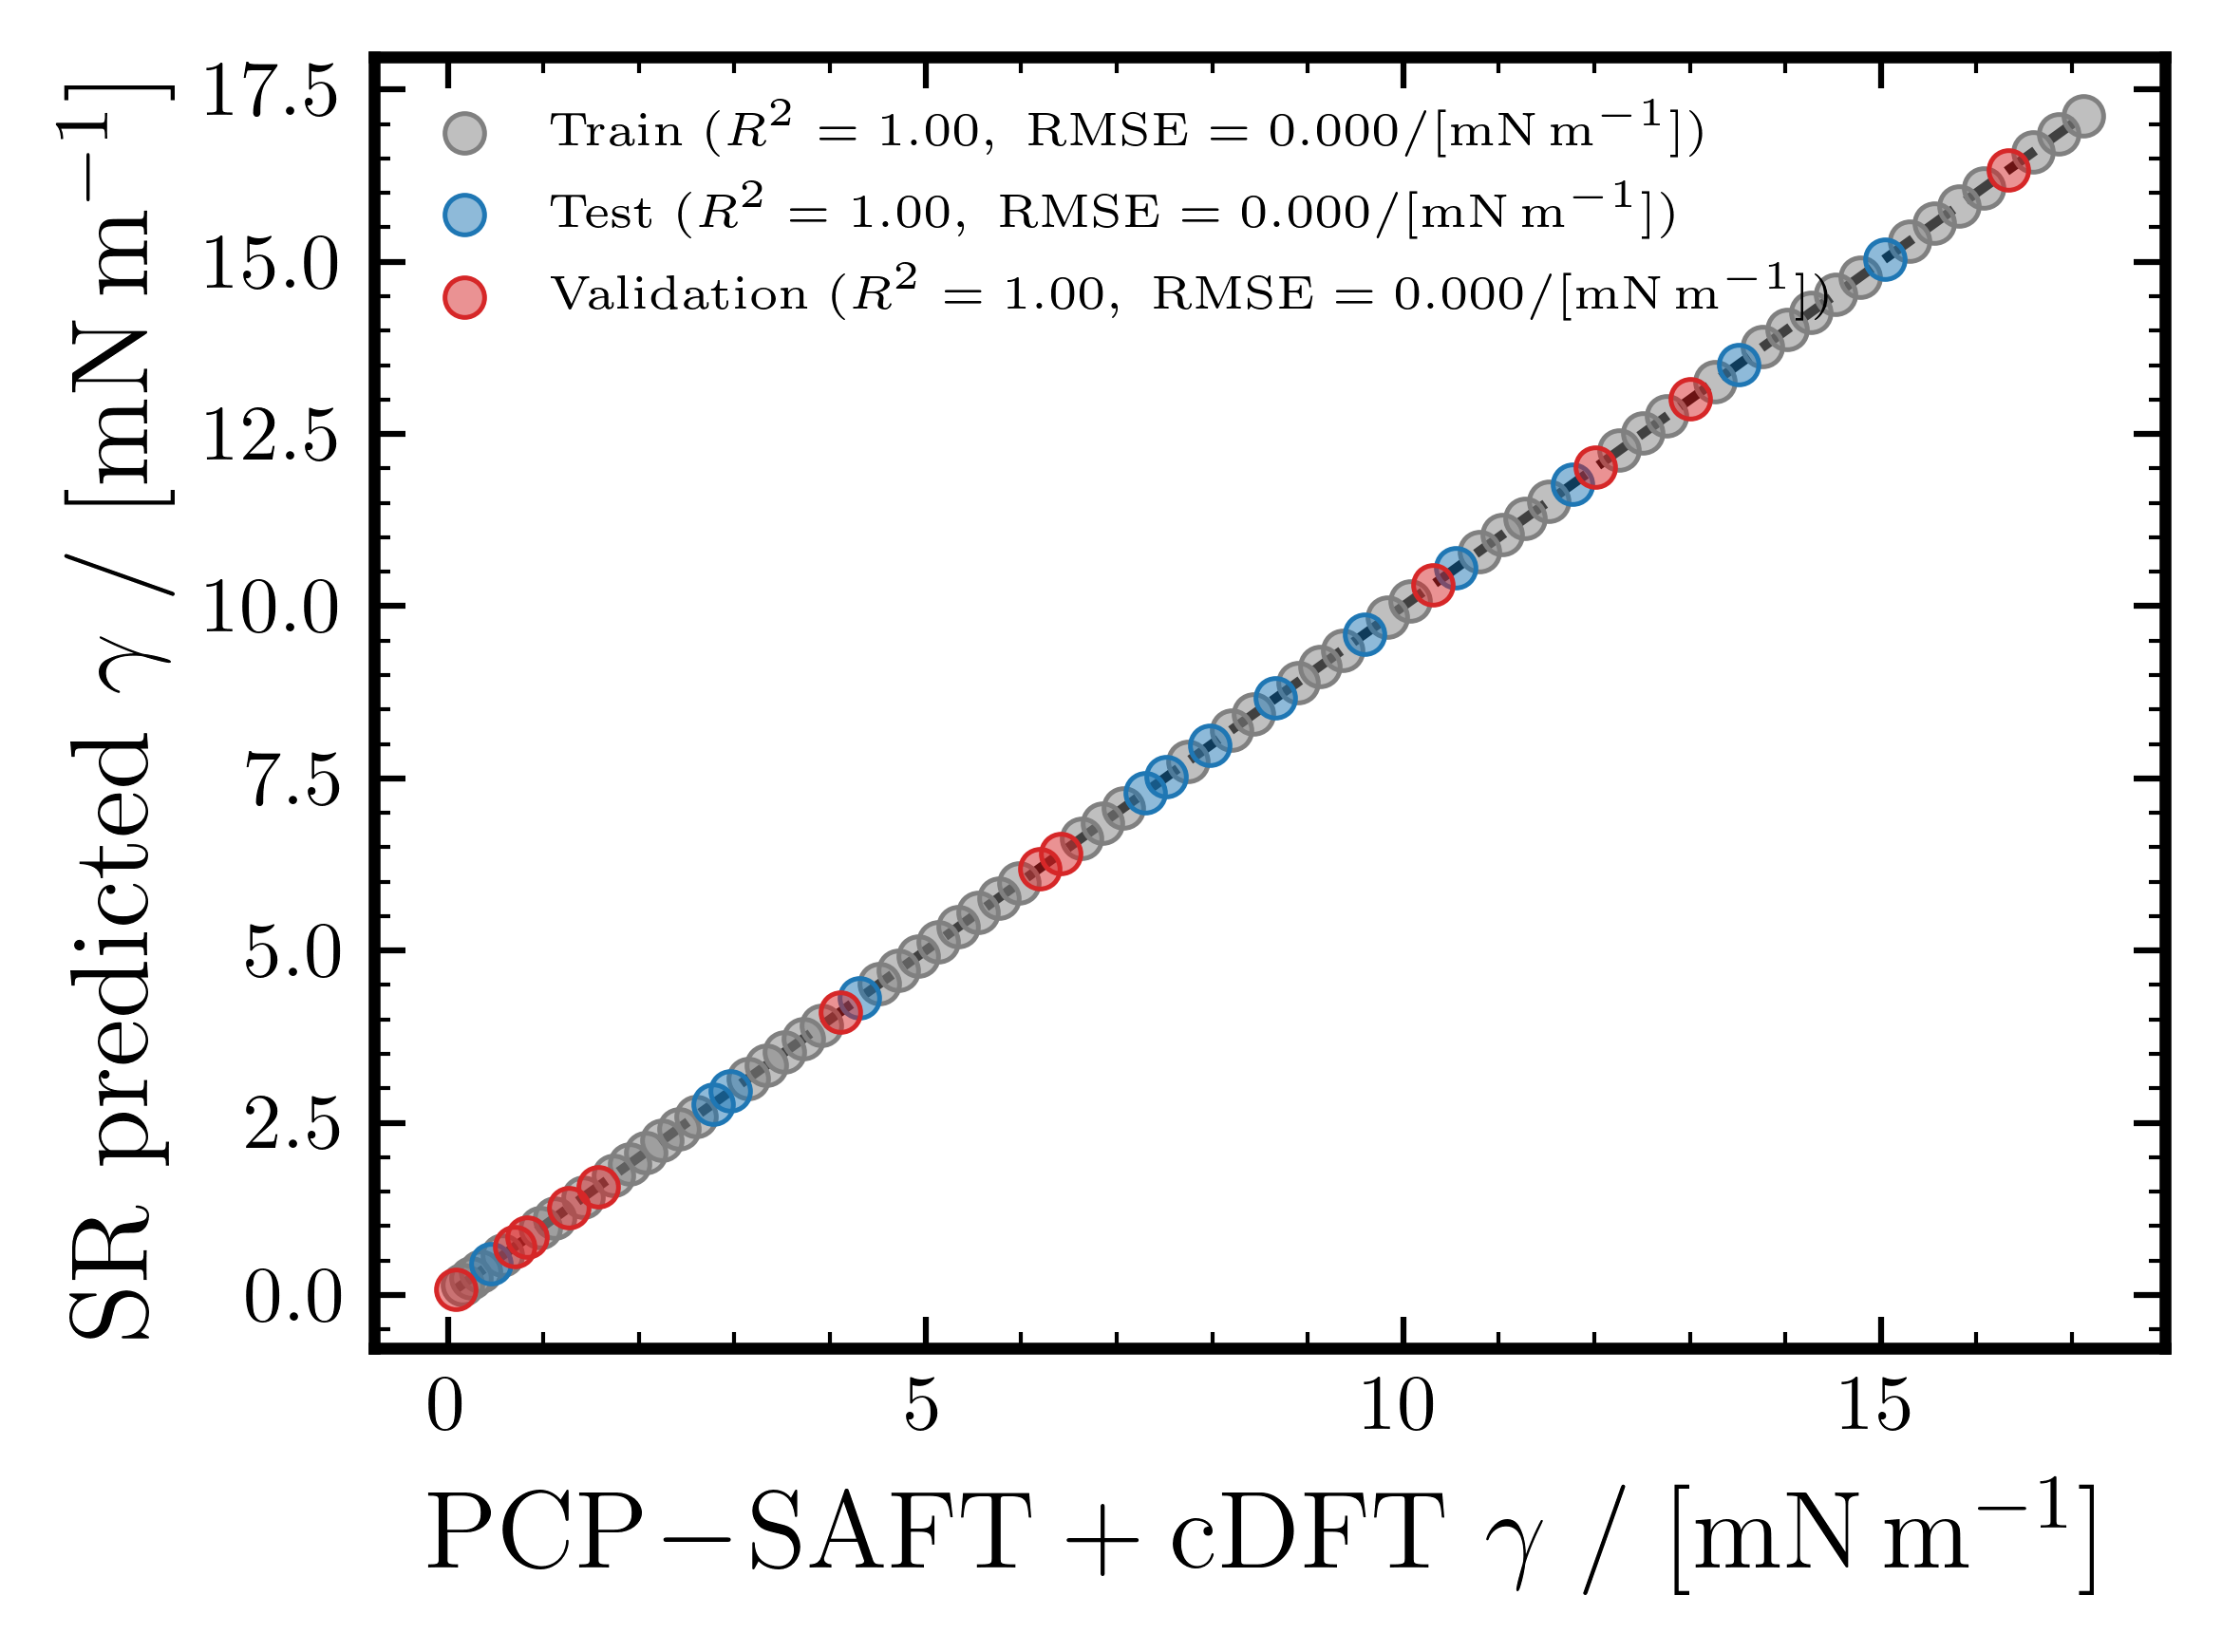

In [10]:
# ── Parity plot — train/val/test split from Julia indices ────────────────
# Requires outputs/split_indices.csv (written by CO2.jl)

def _r2(y, yh):
    ss_res = ((y - yh)**2).sum()
    ss_tot = ((y - y.mean())**2).sum()
    return 1 - ss_res / ss_tot

def _rmse(y, yh):
    return float(((y - yh)**2).mean()**0.5)

_TC      = float(df['Tc'].iloc[0])
_F1_full = 1.0 - df['T_K'].values / _TC
_y_full  = df['gamma'].values
_yh_full = eval(eq_str, {'__builtins__': {}}, {'safepow': safepow, 'F1': _F1_full})

# Load Julia split indices (1-based → convert to 0-based)
_split = pd.read_csv('outputs/split_indices.csv')
_tr_idx  = _split.loc[_split['split'] == 'train', 'index'].values - 1
_val_idx = _split.loc[_split['split'] == 'val',   'index'].values - 1
_te_idx  = _split.loc[_split['split'] == 'test',  'index'].values - 1

_y_tr,  _yh_tr  = _y_full[_tr_idx],  _yh_full[_tr_idx]
_y_val, _yh_val = _y_full[_val_idx], _yh_full[_val_idx]
_y_te,  _yh_te  = _y_full[_te_idx],  _yh_full[_te_idx]

r2_tr,  rmse_tr  = _r2(_y_tr,  _yh_tr),  _rmse(_y_tr,  _yh_tr)
r2_val, rmse_val = _r2(_y_val, _yh_val), _rmse(_y_val, _yh_val)
r2_te,  rmse_te  = _r2(_y_te,  _yh_te),  _rmse(_y_te,  _yh_te)

_lo, _hi = _y_full.min(), _y_full.max()

fig, ax = ps.plot_init()
ax.scatter(_y_tr,  _yh_tr,  s=25,
           facecolors=(0.5, 0.5, 0.5, 0.5),           edgecolors='gray',     linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Train}}\\ (R^2={r2_tr:.2f},\\ \\mathrm{{RMSE}}={rmse_tr:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')
ax.scatter(_y_te,  _yh_te,  s=25,
           facecolors=(0.122, 0.467, 0.706, 0.5),     edgecolors='#1f77b4',  linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Test}}\\ (R^2={r2_te:.2f},\\ \\mathrm{{RMSE}}={rmse_te:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')
ax.scatter(_y_val, _yh_val, s=25,
           facecolors=(0.839, 0.153, 0.157, 0.5),     edgecolors='#d62728',  linewidths=0.6,
           zorder=3, label=f'$\\mathrm{{Validation}}\\ (R^2={r2_val:.2f},\\ \\mathrm{{RMSE}}={rmse_val:.3f} / [\\mathrm{{mN\\,m^{{-1}}}}])$')

ax.plot([_lo, _hi], [_lo, _hi], 'k--', lw=1.2)
ax.set_xlabel(r"$\mathrm{PCP\!-\!SAFT+cDFT}\ \gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\mathrm{SR\ predicted}\ \gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
# ax.set_title(f'Parity Plot - SR Eq.{best_idx}',   fontsize=ps.title_fontsize)
ax.legend(loc='upper left', fontsize=ps.legend_fontsize*0.75, frameon=False)
ax.minorticks_on()
plt.tight_layout()
plt.show()

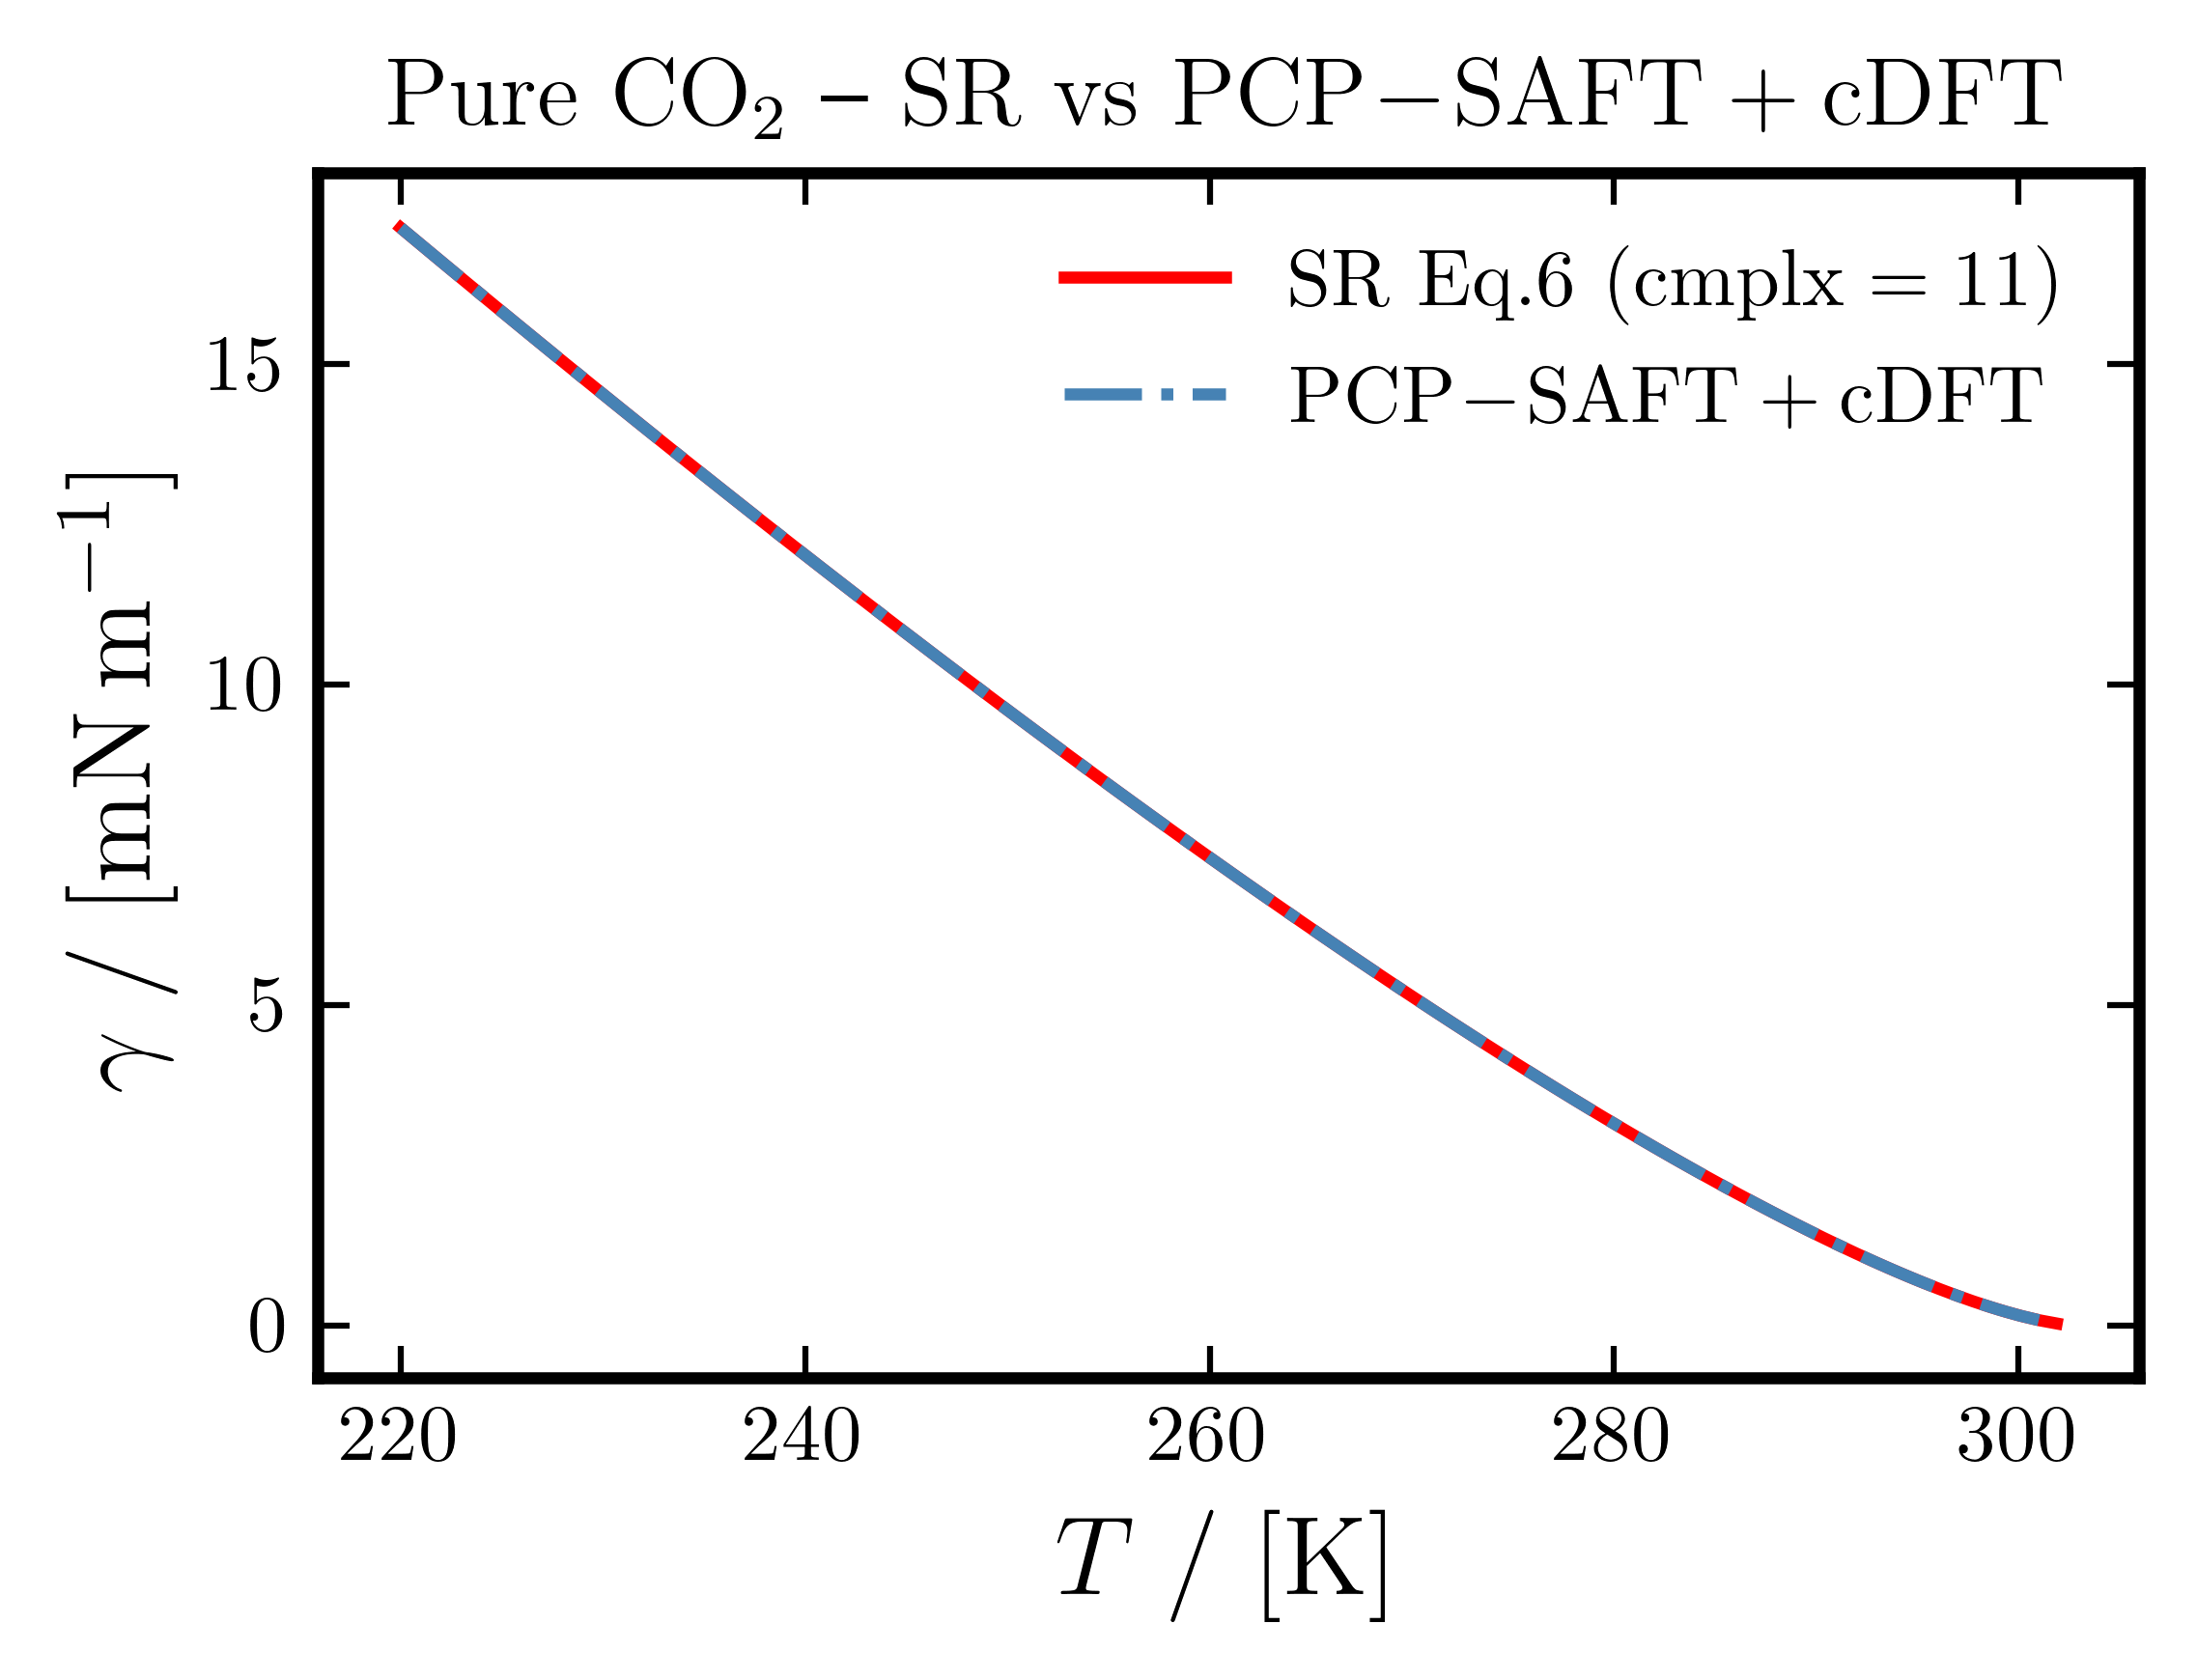

In [11]:
fig, ax = ps.plot_init()
ax.plot(T_range, sigma, "-",  markersize=4, color="red",       label=f"$\\mathrm{{SR\\ Eq.}}{best_idx}\\ (\\mathrm{{cmplx}}={int(chosen['Complexity'])})$")
ax.plot(df['T_K'], df['gamma'], "-.", markersize=4, color="steelblue", label=r"$\mathrm{PCP\!-\!SAFT+cDFT}$")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$",fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$",fontsize=ps.label_fontsize)
ax.set_title(r"$\mathrm{Pure\ CO_{2}}$ -- $\mathrm{SR\ vs\ PCP\!-\!SAFT+cDFT}$", fontsize=ps.title_fontsize)
ax.legend(loc='best', frameon=False)
plt.tight_layout()
plt.show()

In [12]:
# Compute pure surface tension using InterfacialTension from Interfacethermopy

ift = InterfacialTension('Mulero_2012.json')

rp_path = "/home/darshan/Software/REFPROP/REFPROP-cmake/build"
ift.ctREFPROP_init(rp_path)
fluid_name = "CO2"
T_range_pure = np.arange(220, 300, 1)

gamma_pure = []
for T in T_range_pure:
    gamma_T, T_used = ift.compute_gamma_pure(T, fluid_name, key='Parachor')
    gamma_pure.append(gamma_T)

gamma_pure = np.array(gamma_pure)

REFPROP version = 10.0
GERG-2008 model = Disabled


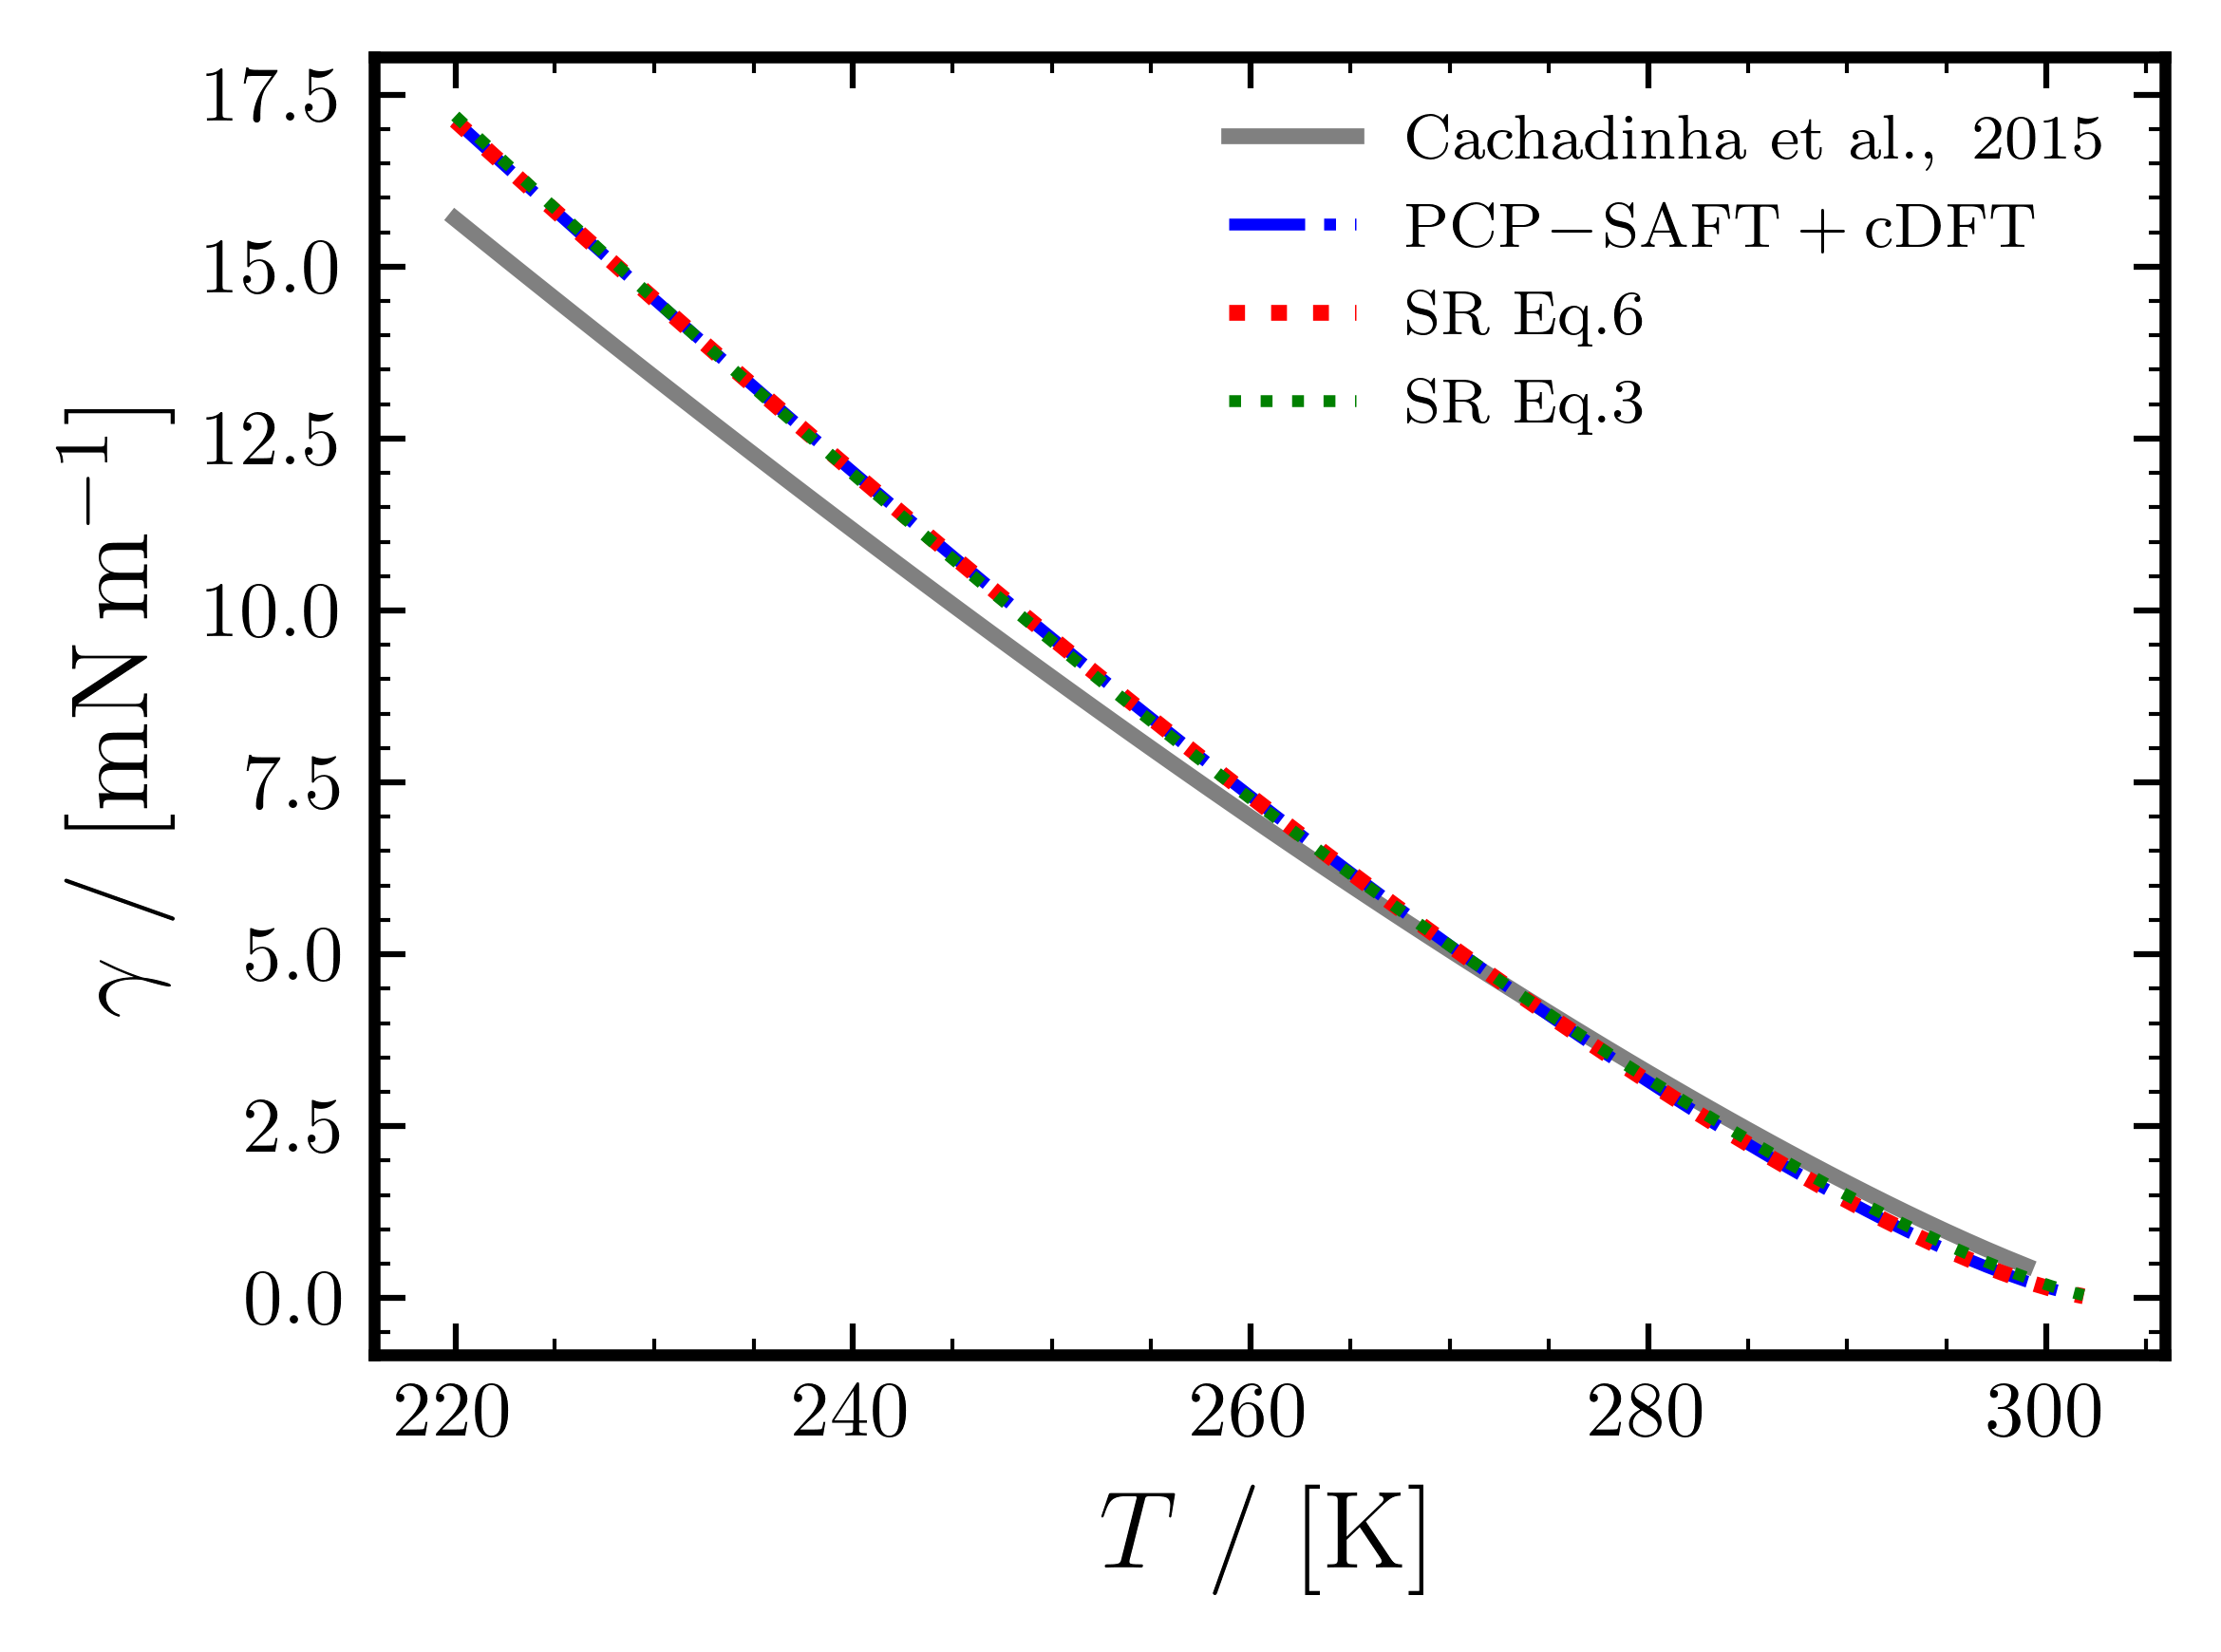

In [13]:
# Plot comparison
_eq3_str = hof_df.iloc[2]["Equation"]
_sigma3  = eval(_eq3_str, {"__builtins__": {}}, {"safepow": safepow, "F1": F1})

fig, ax = ps.plot_init()
ax.plot(T_range_pure, gamma_pure,  "-",  lw=2,        color="grey",    label=r"$\mathrm{Cachadinha\ et\ al.,\ 2015}$")
ax.plot(df['T_K'],    df['gamma'], "-.", markersize=4, color="blue",     label=r"$\mathrm{PCP\!-\!SAFT+cDFT}$")
ax.plot(T_range,      sigma,       ":",  lw=2,         color="red",      label=f"$\\mathrm{{SR\\ Eq.{best_idx}}}$")
ax.plot(T_range,      _sigma3,     ":",  lw=1.5,       color="green",   label=r"$\mathrm{SR\ Eq.3}$")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$",               fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN \, m^{-1}}]$", fontsize=ps.label_fontsize)
ax.legend(loc='best', fontsize=ps.legend_fontsize, frameon=False)
ax.minorticks_on()
plt.tight_layout()
plt.show()